In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [99]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [101]:
df["gender"] = df["sex"].map({"male": 1, "female": 0})
df["is_smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df.drop(columns=["sex", "smoker"], inplace=True)
df.head()

,age,bmi,children,region,charges,gender,is_smoker
0,19,27.900,0,southwest,16884.92400,0,1
1,18,33.770,1,southeast,1725.55230,1,0
2,28,33.000,3,southeast,4449.46200,1,0
3,33,22.705,0,northwest,21984.47061,1,0
4,32,28.880,0,northwest,3866.85520,1,0


In [102]:
regions = np.array(df["region"].unique())

In [103]:
for region in regions:
    df[region] = (df["region"] == region).astype(int)
df.drop(columns="region", inplace= True)
df.head()

,age,bmi,children,charges,gender,is_smoker,southwest,southeast,northwest,northeast
0,19,27.900,0,16884.92400,0,1,1,0,0,0
1,18,33.770,1,1725.55230,1,0,0,1,0,0
2,28,33.000,3,4449.46200,1,0,0,1,0,0
3,33,22.705,0,21984.47061,1,0,0,0,1,0
4,32,28.880,0,3866.85520,1,0,0,0,1,0


In [104]:
means = []
stds = []
for column in ["age", "bmi", "children", "charges"]:
    mean = df[column].mean()
    std = df[column].std()
    means.append(mean)
    stds.append(std)
    df[column] = (df[column] - mean) / std

In [105]:
target = np.array(df["charges"])
X = np.array(df.drop(columns=["charges"]))
print(target)
print(X)

[ 0.2984722  -0.95333272 -0.72840232 ... -0.96123683 -0.93001377
  1.31056344]
[[-1.4382265  -0.45315057 -0.90827406 ...  0.          0.
   0.        ]
 [-1.50940108  0.50943062 -0.07873775 ...  1.          0.
   0.        ]
 [-0.7976553   0.38316358  1.58033487 ...  1.          0.
   0.        ]
 ...
 [-1.50940108  1.01449877 -0.90827406 ...  1.          0.
   0.        ]
 [-1.29587735 -0.79751522 -0.90827406 ...  0.          0.
   0.        ]
 [ 1.55110577 -0.26129026 -0.90827406 ...  0.          1.
   0.        ]]


In [106]:
weights = np.zeros(X.shape[1] + 1)
bias = np.ones((X.shape[0], 1))
X = np.hstack((bias, X))
print(X.shape)
print(weights.shape)

(1338, 10)
(10,)


In [107]:
learning_rate = 0.01
for i in range(0, 10000):
    h_of_x = X @ weights
    deltas = h_of_x - target
    for index in range(0, weights.shape[0]):
        gradient = deltas * X[:, index]
        weights[index] = weights[index] - learning_rate * gradient.mean()


In [108]:
predictions = X @ weights
error = predictions - target
mse = error ** 2
print(mse.mean())

0.2489008017502307


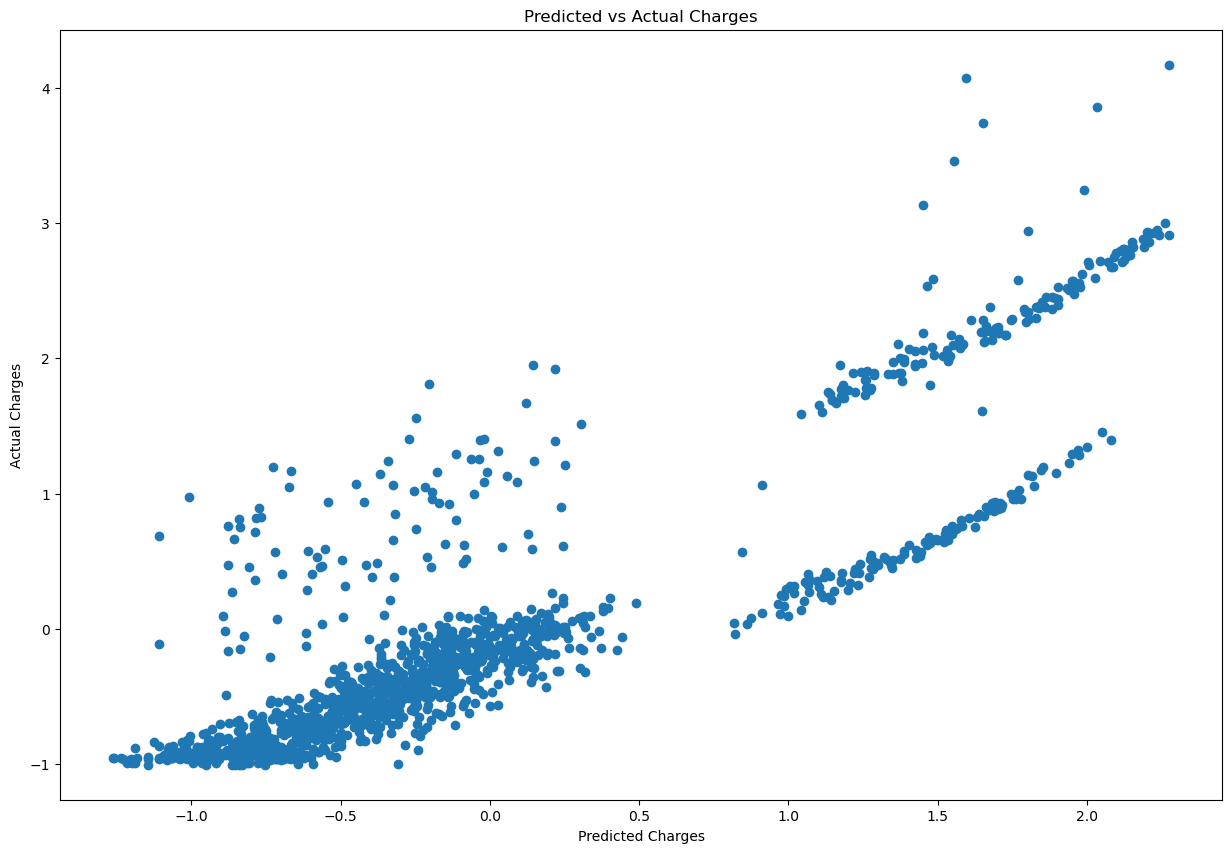

In [109]:
plt.figure(figsize=(15, 10))
plt.scatter(predictions, target)
plt.xlabel("Predicted Charges")
plt.ylabel("Actual Charges")
plt.title("Predicted vs Actual Charges")
plt.show()